In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("15-gym_crowdedness.csv")

In [3]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [5]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [6]:
df["date"] = pd.to_datetime(df["date"], utc = True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   number_people         62184 non-null  int64              
 1   date                  62184 non-null  datetime64[ns, UTC]
 2   timestamp             62184 non-null  int64              
 3   day_of_week           62184 non-null  int64              
 4   is_weekend            62184 non-null  int64              
 5   is_holiday            62184 non-null  int64              
 6   temperature           62184 non-null  float64            
 7   is_start_of_semester  62184 non-null  int64              
 8   is_during_semester    62184 non-null  int64              
 9   month                 62184 non-null  int64              
 10  hour                  62184 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(1), int64(9)
memory usage: 5.2 M

In [11]:
df["year"] = df["date"].dt.year

In [12]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,71.76,0,0,8,17,2015
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,71.76,0,0,8,17,2015
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,71.76,0,0,8,17,2015
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,71.76,0,0,8,17,2015
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,71.76,0,0,8,17,2015


In [13]:
df["year"].unique()

array([2015, 2016, 2017], dtype=int32)

In [14]:
df.drop("date", axis=1, inplace=True)

In [15]:
df.head()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,61211,4,0,0,71.76,0,0,8,17,2015
1,45,62414,4,0,0,71.76,0,0,8,17,2015
2,40,63015,4,0,0,71.76,0,0,8,17,2015
3,44,63616,4,0,0,71.76,0,0,8,17,2015
4,45,64217,4,0,0,71.76,0,0,8,17,2015


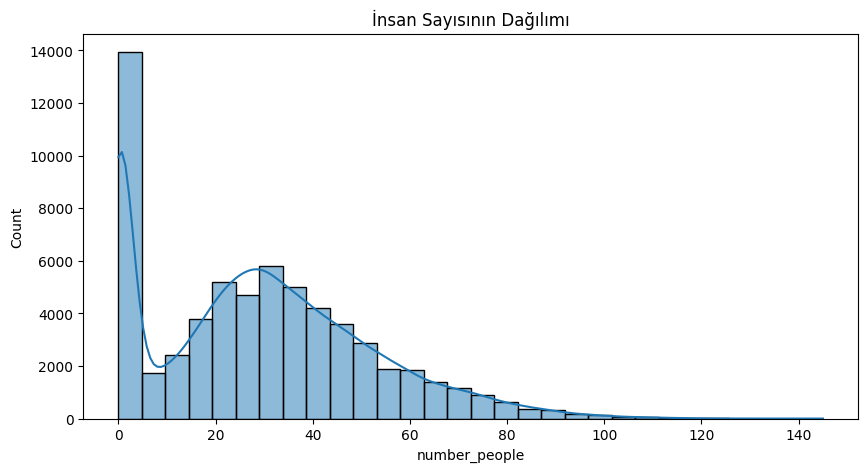

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='number_people', kde=True, bins=30)
plt.title('İnsan Sayısının Dağılımı')
plt.show()

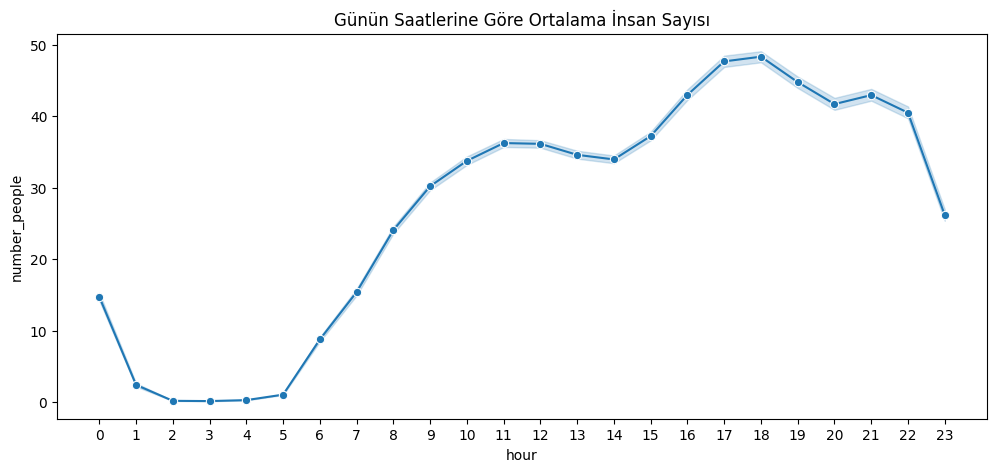

In [ ]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='hour', y='number_people', marker='o')
plt.title('Günün Saatlerine Göre Ortalama İnsan Sayısı')
plt.xticks(range(0, 24)) 
plt.show()

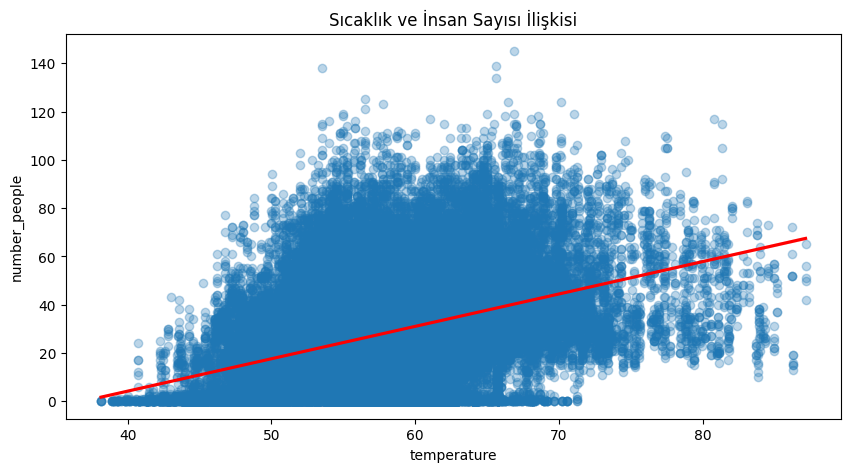

In [20]:
plt.figure(figsize=(10, 5))
sns.regplot(data=df, x='temperature', y='number_people', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Sıcaklık ve İnsan Sayısı İlişkisi')
plt.show()

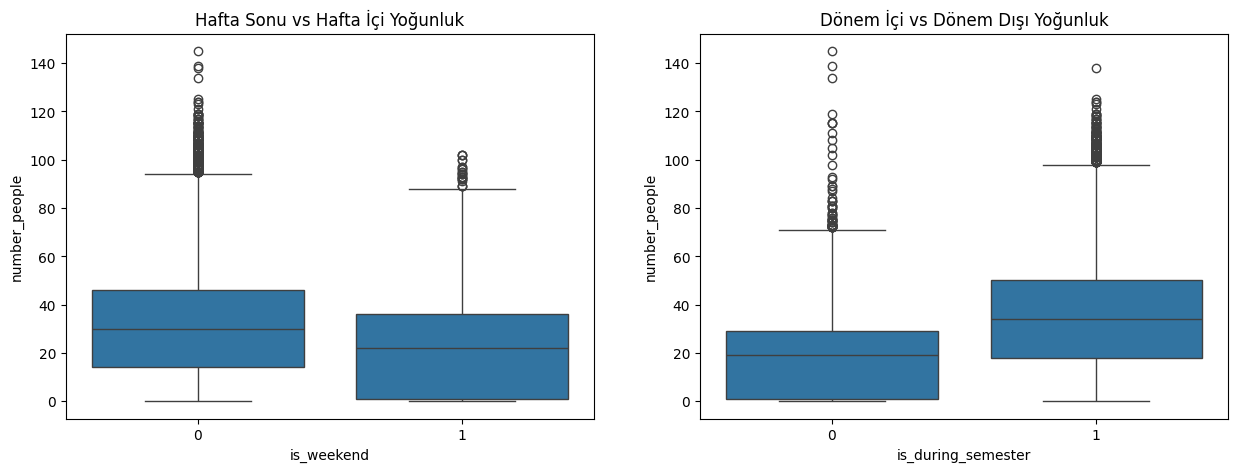

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='is_weekend', y='number_people', ax=axes[0])
axes[0].set_title('Hafta Sonu vs Hafta İçi Yoğunluk')

sns.boxplot(data=df, x='is_during_semester', y='number_people', ax=axes[1])
axes[1].set_title('Dönem İçi vs Dönem Dışı Yoğunluk')

plt.show()

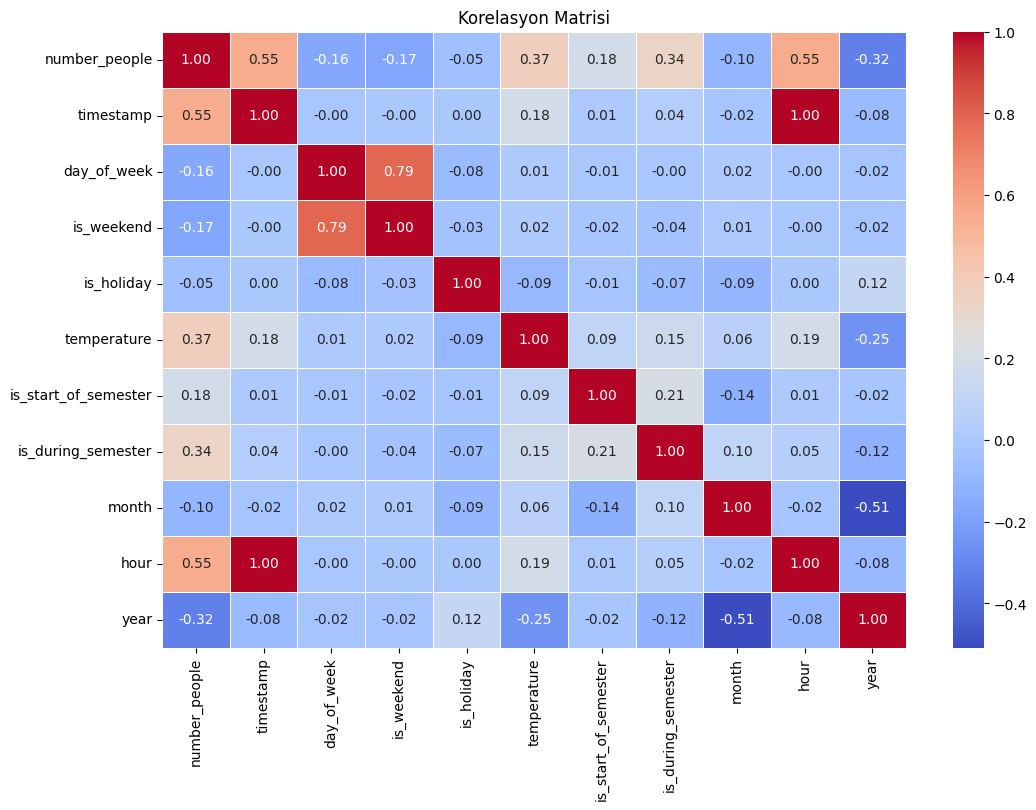

In [23]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korelasyon Matrisi')
plt.show()

In [25]:
df.drop("timestamp", axis=1, inplace=True)

In [26]:
df.head()

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,4,0,0,71.76,0,0,8,17,2015
1,45,4,0,0,71.76,0,0,8,17,2015
2,40,4,0,0,71.76,0,0,8,17,2015
3,44,4,0,0,71.76,0,0,8,17,2015
4,45,4,0,0,71.76,0,0,8,17,2015


In [27]:
X= df.drop("number_people", axis=1)
y = df["number_people"]

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [31]:
def calculate_model_metrics(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [32]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor()
}

In [34]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])
    print("Evaluation for Training Set")
    print("RMSE : ", model_train_rmse)
    print("Mean Absolute Error : ", model_train_mae)
    print("R2 Score : ", model_train_r2)

    print("------------------------------")

    print("Evaluation for Test Set")
    print("RMSE : ", model_test_rmse)
    print("Mean Absolute Error : ", model_test_mae)
    print("R2 Score : ", model_test_r2)
 
    print("------------------------------")
    print("\n")


LinearRegression()
Evaluation for Training Set
RMSE :  14.322500408269727
Mean Absolute Error :  10.733469936454325
R2 Score :  0.5999639521710998
------------------------------
Evaluation for Test Set
RMSE :  14.45063290337055
Mean Absolute Error :  10.779752371029561
R2 Score :  0.5989271376662774
------------------------------


Lasso()
Evaluation for Training Set
RMSE :  14.569122351126817
Mean Absolute Error :  10.945189874221992
R2 Score :  0.5860687429058037
------------------------------
Evaluation for Test Set
RMSE :  14.703511215751082
Mean Absolute Error :  10.970594902476911
R2 Score :  0.5847671974050241
------------------------------


Ridge()
Evaluation for Training Set
RMSE :  14.322500413912243
Mean Absolute Error :  10.733479178820698
R2 Score :  0.5999639518559021
------------------------------
Evaluation for Test Set
RMSE :  14.450633329986024
Mean Absolute Error :  10.779759559023008
R2 Score :  0.5989271139851151
------------------------------


KNeighborsRegresso

In [35]:
knn_params = {"n_neighbors": [2,3,10,20,40,50]}
rf_params = {
    "max_depth": [5,8,10,15,None],
    "max_features": ["sqrt", "log2", 5, 7, 10],
    "min_samples_split": [2,8,12,20],
    "n_estimators": [100, 200, 500, 1000]
}

In [36]:
from sklearn.model_selection import RandomizedSearchCV

In [37]:
randomcv_models = [
    ("KNN", KNeighborsRegressor(), knn_params),
    ("RF", RandomForestRegressor(), rf_params)    
]

In [39]:
for name, model, params in randomcv_models:
    randomcv = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter= 100, cv=3, n_jobs = -1)
    randomcv.fit(X_train, y_train)
    print("best params fot: ", name, randomcv.best_params_)

c:\Users\altin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=100. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


best params fot:  KNN {'n_neighbors': 2}
best params fot:  RF {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}


In [40]:
models = {
    "K-Neighbors Regressor": KNeighborsRegressor(n_neighbors=2),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=500,
    min_samples_split=2, max_features=7, max_depth=None)
}

In [41]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])
    print("Evaluation for Training Set")
    print("RMSE : ", model_train_rmse)
    print("Mean Absolute Error : ", model_train_mae)
    print("R2 Score : ", model_train_r2)

    print("------------------------------")

    print("Evaluation for Test Set")
    print("RMSE : ", model_test_rmse)
    print("Mean Absolute Error : ", model_test_mae)
    print("R2 Score : ", model_test_r2)
 
    print("------------------------------")
    print("\n")

KNeighborsRegressor(n_neighbors=2)
Evaluation for Training Set
RMSE :  5.459915271471292
Mean Absolute Error :  3.554365538830996
R2 Score :  0.9418655928537132
------------------------------
Evaluation for Test Set
RMSE :  6.901495818935785
Mean Absolute Error :  4.6316737424417855
R2 Score :  0.9085179266857696
------------------------------


RandomForestRegressor(max_features=7, n_estimators=500)
Evaluation for Training Set
RMSE :  4.710652090019765
Mean Absolute Error :  3.197077349946556
R2 Score :  0.9567263526337451
------------------------------
Evaluation for Test Set
RMSE :  6.42488193081974
Mean Absolute Error :  4.291961067731967
R2 Score :  0.9207170424638059
------------------------------


